# Notebook Overview
The last linear model was able to learn overall linear trend of the data, but failed to capture complex non linear relationships between different features due to omssio of non linear acctivations.

## Objective

In this notebook non linear activations such as relu would be used to see if those small minute details that were unable to be captured in the previous dataset can be able to be observed.

In [1]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.layers import Dense

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')


--2026-05-25 18:26:33--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.2.33, 172.67.70.149, 104.26.3.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.2.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0s      

2026-05-25 18:26:34 (148 MB/s) - ‘insurance.csv’ saved [50264/50264]



In [3]:
dataset.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [4]:
# size of dataset
dataset.shape

(1338, 7)

In [5]:
# investigating for null values

dataset.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [6]:
# isolating labels

labels = dataset.pop("expenses")

In [7]:
# unique regions
dataset['region'].nunique()

4

In [8]:
dataset.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.9,0,yes,southwest
1,18,male,33.8,1,no,southeast
2,28,male,33.0,3,no,southeast
3,33,male,22.7,0,no,northwest
4,32,male,28.9,0,no,northwest


In [9]:
# converting categorical columns to onehot encode

categorical = ["sex","smoker","region"]
# drop first column for statistical significance

dataset = pd.get_dummies(dataset, columns = categorical, drop_first = True,dtype=int)

In [10]:
dataset.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,0,1,0,0,1
1,18,33.8,1,1,0,0,1,0
2,28,33.0,3,1,0,0,1,0
3,33,22.7,0,1,0,1,0,0
4,32,28.9,0,1,0,1,0,0


In [11]:
# normalizing data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dataset[["age","bmi","children"]] = scaler.fit_transform(dataset[["age","bmi","children"]])

In [12]:
dataset[['age','bmi','children']] # standardized

,age,bmi,children
0,-1.438764,-0.453646,-0.908614
1,-1.509965,0.514186,-0.078767
2,-0.797954,0.382954,1.580926
3,-0.441948,-1.306650,-0.908614
4,-0.513149,-0.289606,-0.908614
...,...,...,...
1333,0.768473,0.054876,1.580926
1334,-1.509965,0.202511,-0.908614
1335,-1.509965,1.022707,-0.908614
1336,-1.296362,-0.798128,-0.908614


In [13]:
X = dataset.values
Y = labels.values

In [14]:
# split and shuffle
from sklearn.model_selection import train_test_split

train_dataset,test_dataset,train_labels,test_labels = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [15]:
test_labels.shape

(268,)

In [16]:
train_dataset.shape

(1070, 8)

In [33]:
# model creation

from keras import Sequential
from keras.layers import Input
from keras.layers import Dense

# introducing non linearity
model = Sequential()
model.add(Input(shape = (train_dataset.shape[1],)))
model.add(Dense(64, activation= 'relu'))
model.add(Dense(32, activation= 'relu'))
model.add(Dense(1, activation = 'linear'))

In [34]:
# Early stopping to prevent overfitting

from keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [35]:
# compile model

model.compile(optimizer='adam',loss = 'mse',metrics = ['mae', 'mse'])

In [36]:
'''
fitting model
converting the categorical columns to floats as they are currently bools
'''
model.fit(train_dataset,train_labels,epochs = 500,batch_size =32,validation_split = 0.2,callbacks= [early_stop])

Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 325462432.0000 - mae: 13518.3750 - mse: 325462432.0000 - val_loss: 310345152.0000 - val_mae: 12654.7188 - val_mse: 310345152.0000
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325428704.0000 - mae: 13517.1963 - mse: 325428704.0000 - val_loss: 310304096.0000 - val_mae: 12653.2266 - val_mse: 310304096.0000
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325363616.0000 - mae: 13515.0225 - mse: 325363616.0000 - val_loss: 310217632.0000 - val_mae: 12650.2031 - val_mse: 310217632.0000
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325226816.0000 - mae: 13510.5674 - mse: 325226816.0000 - val_loss: 310041600.0000 - val_mae: 12644.2080 - val_mse: 310041600.0000
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 324957920.0000 - mae: 13502.0322 - mse: 324957920.0000 - val_loss: 309712736.0000 - val_mae: 12633.2334 - val_mse: 309712736.0000
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

9/9 - 0s - 20ms/step - loss: 25032562.0000 - mae: 3222.8848 - mse: 25032562.0000
Testing set Mean Abs Error: 3222.88 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


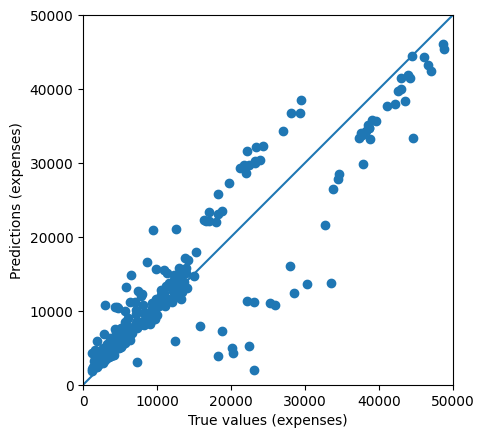

In [37]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset)

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)